# GRB clustering

Discover clustering methods and conclude with some observation about Gamma-Ray-Bust.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from sklearn.cluster import KMeans, MeanShift
from sklearn import preprocessing
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, classification_report

In [10]:
load = np.loadtxt("Summary_GRB.txt", dtype='str',unpack='True')

### Warm up

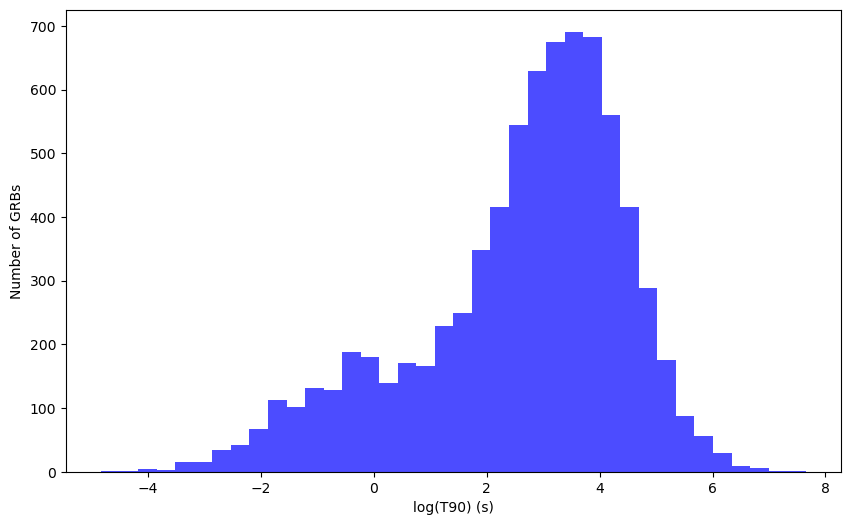

In [11]:
T90 = np.array(load[6], dtype=float)
mask = (T90 > 0)
T90 = T90[mask]

plt.figure(figsize=(10, 6))
plt.hist(np.log(T90), bins='scott', color='blue', alpha=0.7)
plt.xlabel('log(T90) (s)')
plt.ylabel('Number of GRBs')
plt.show()

In [12]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
 |  
 |  K-Means clustering.
 |  
 |  Read more in the :ref:`User Guide <k_means>`.
 |  
 |  Parameters
 |  ----------
 |  
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |  
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |  
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |  
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to t

Preprocessig is needed to make work the distance that minimize in the loss function of K-mean.

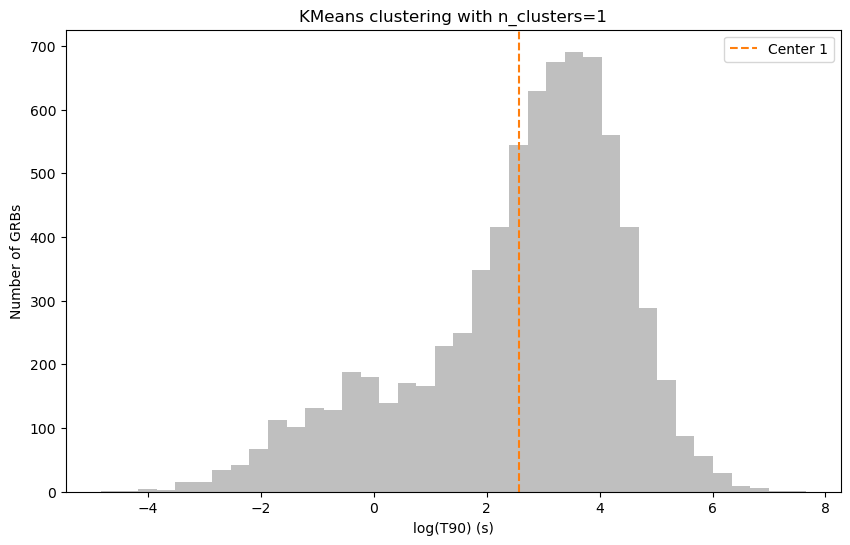

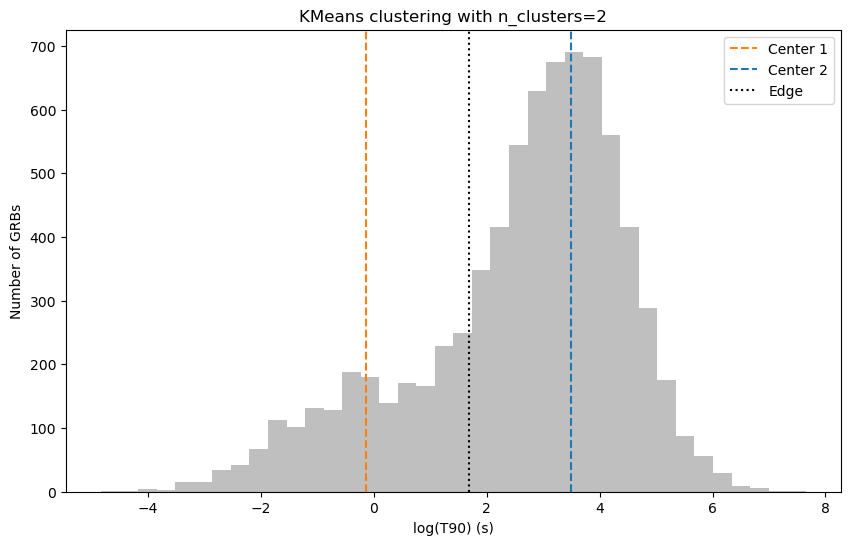

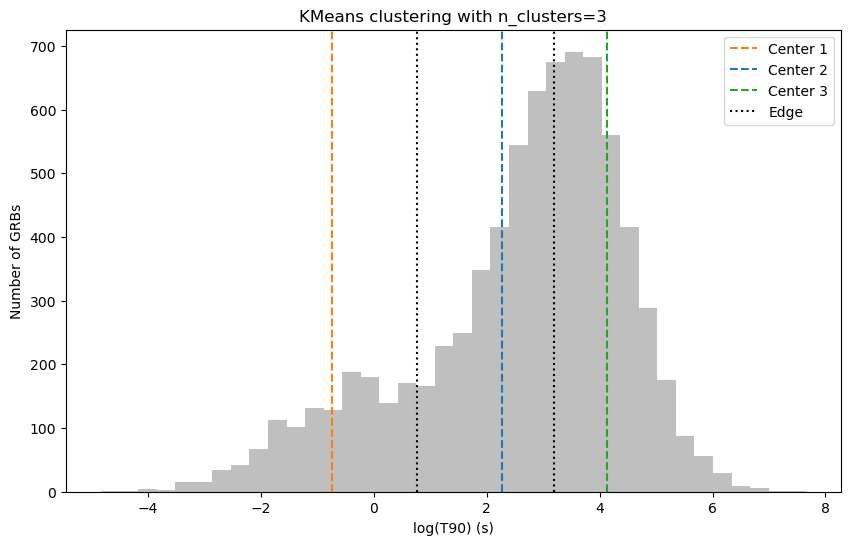

In [13]:
scaler = preprocessing.StandardScaler()

X = np.log(T90).reshape(-1, 1)
X = scaler.fit_transform(X)
colors = ['C1', 'C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

for n in range(1, 4):
    clKM = KMeans(n_clusters=n, random_state=1234, n_init='auto')
    labels = clKM.fit_predict(X)
    centers = scaler.inverse_transform(clKM.cluster_centers_).ravel()
    centers = np.sort(centers)

    plt.figure(figsize=(10, 6))
    plt.hist(scaler.inverse_transform(X), bins='scott', color='gray', alpha=0.5)
    for i in enumerate(centers):
        plt.axvline(x=i[1], color=colors[i[0]], linestyle='--', label=f'Center {i[0]+1}')
    if n > 1:
        edges = (centers[:-1] + centers[1:]) / 2
        for edge_idx, edge in enumerate(edges):
            plt.axvline(x=edge, color='black', linestyle=':', linewidth=1.5, label='Edge' if edge_idx == 0 else None)

    plt.xlabel('log(T90) (s)')
    plt.ylabel('Number of GRBs')
    plt.title(f'KMeans clustering with n_clusters={n}')
    plt.legend()
    plt.show()

### More features

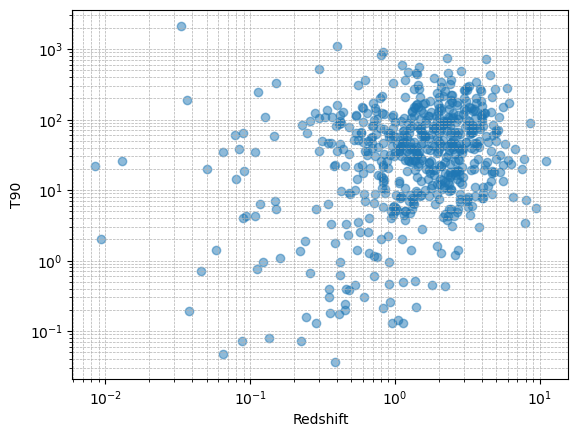

In [14]:
redshift = np.array(load[11], dtype=float)
T90 = np.array(load[6], dtype=float)

mask = (redshift > 0) & (T90 > 0)

plt.scatter(redshift[mask], T90[mask], alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()


In [15]:
nclusters = 5
data = np.column_stack((redshift[mask], T90[mask]))
data_scaled = scaler.fit_transform(data)

In [16]:
clKM = KMeans(n_clusters=nclusters, n_init='auto')
clKM.fit(data_scaled)

KMeans(n_clusters=5)

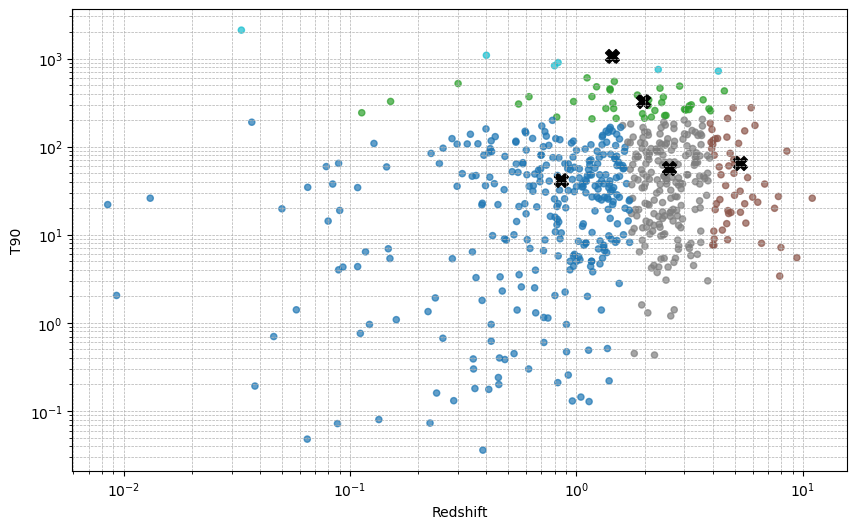

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=clKM.labels_, cmap='tab10', s=20, alpha=0.7)
plt.scatter(scaler.inverse_transform(clKM.cluster_centers_)[:, 0], scaler.inverse_transform(clKM.cluster_centers_)[:, 1], c='black', s=100, marker='X', label='Cluster Centers')
plt.xlabel('Redshift')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)


In [18]:
clMS = MeanShift(bandwidth=1.0)
clMS.fit(data_scaled)

MeanShift(bandwidth=1.0)

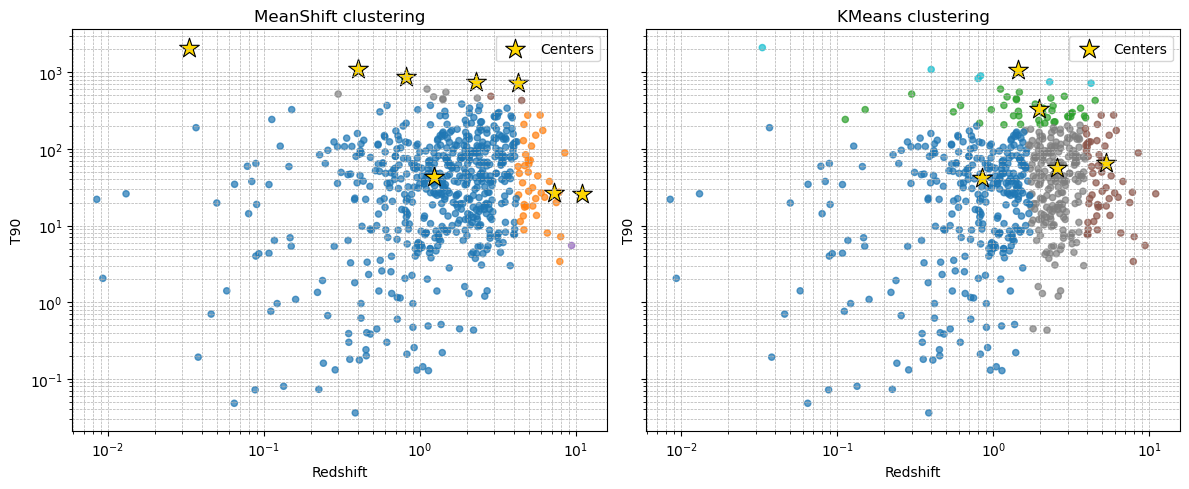

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(data[:, 0], data[:, 1], c=clMS.labels_, cmap='tab10', s=20, alpha=0.7)
axes[0].set_title('MeanShift clustering')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('T90')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[1].scatter(data[:, 0], data[:, 1], c=clKM.labels_, cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('KMeans clustering')
axes[1].set_xlabel('Redshift')
axes[1].set_ylabel('T90')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

centersKM = scaler.inverse_transform(clKM.cluster_centers_)
centersMS = scaler.inverse_transform(clMS.cluster_centers_)

axes[0].scatter(
    centersMS[:, 0], centersMS[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)
axes[1].scatter(
    centersKM[:, 0], centersKM[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

**Comment:**

- It's an unsupervised learning: we are sensible on number of cluster wich we can fix with cross validation. Comparison beetween the two method is difficult because of different loss function; there are still method probabily in the licterature.

- MeanShift is very sensible to bandwith input.

- When we have a single point cluster could we interprete this as outliers?

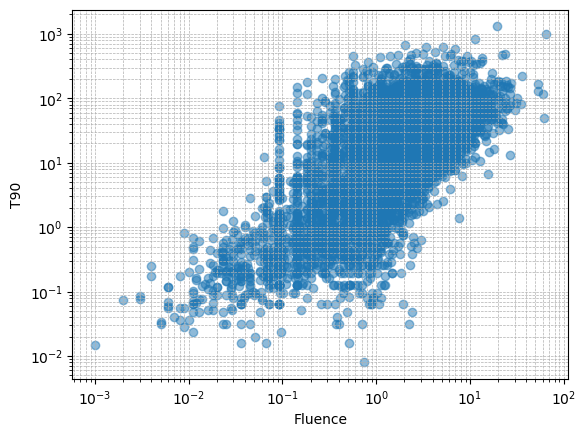

In [20]:
fluence = np.array(load[7], dtype=float)

mask = (fluence > 0) & (T90 > 0)
data = np.column_stack((fluence[mask], T90[mask]))

data_scaled = scaler.fit_transform(data)

plt.scatter(data[:, 0], data[:, 1], alpha=0.5)
plt.title('')
plt.xlabel('Fluence')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()


In [21]:
nclusters = 3
clKM = KMeans(n_clusters=nclusters, n_init='auto')

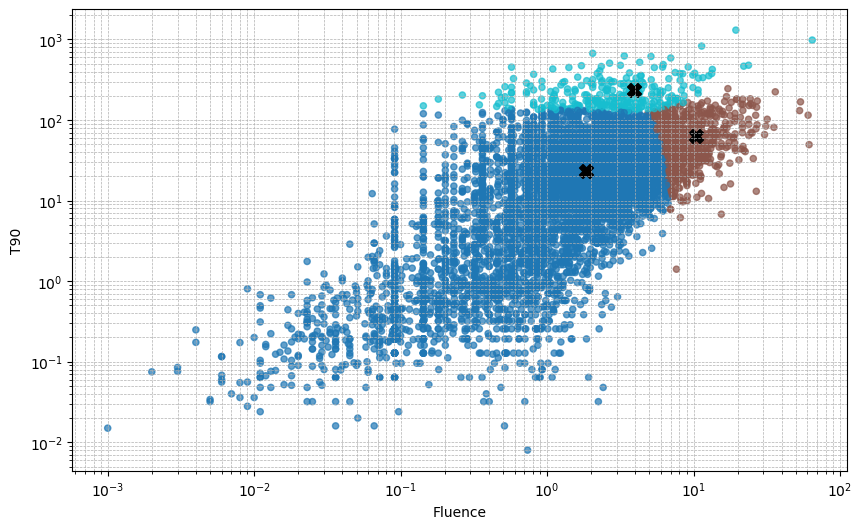

In [22]:
clKM.fit(data_scaled)
centers = clKM.cluster_centers_ 
labels = clKM.labels_ 


plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=20, alpha=0.7)
plt.scatter(scaler.inverse_transform(centers)[:, 0], scaler.inverse_transform(centers)[:, 1], c='black', s=100, marker='X', label='Cluster Centers')
plt.xlabel('Fluence')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [23]:
clMS = MeanShift(bandwidth=1.0)
clMS.fit(data_scaled)

MeanShift(bandwidth=1.0)

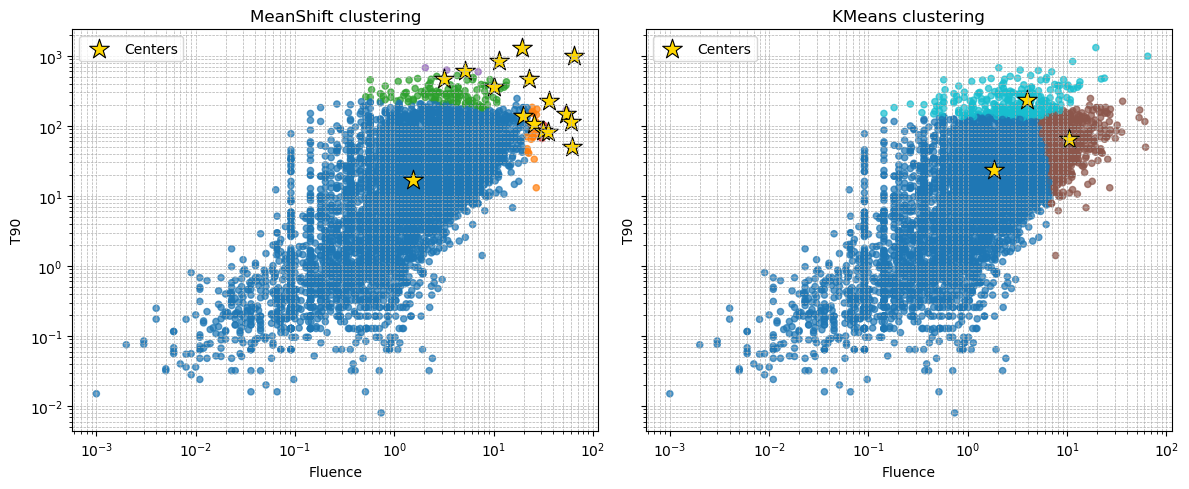

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(data[:, 0], data[:, 1], c=clMS.labels_, cmap='tab10', s=20, alpha=0.7)
axes[0].set_title('MeanShift clustering')
axes[0].set_xlabel('Fluence')
axes[0].set_ylabel('T90')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[1].scatter(data[:, 0], data[:, 1], c=clKM.labels_, cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('KMeans clustering')
axes[1].set_xlabel('Fluence')
axes[1].set_ylabel('T90')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

centersKM = scaler.inverse_transform(clKM.cluster_centers_)
centersMS = scaler.inverse_transform(clMS.cluster_centers_)

axes[0].scatter(
    centersMS[:, 0], centersMS[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)
axes[1].scatter(
    centersKM[:, 0], centersKM[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

**Comment:**

- We are still very sensible to bandwith. We surely prefer the KMeans alghortihm in this case. We are dealing with some sparse data and KDE isn't the best prescription.

- If, looking to MeanShift, we used the outliers interpretation we would have done wrong compared with what's the output of KMeans.

### Cross Validation Routine & Clustering

Let's use the scikit library to compare different clustering models. Since clustering is an unsupervised learning task, we need a metric to evaluate the quality of the results.

One of the most common metrics is the **Silhouette Score**, defined as


$$ s_i = \frac{b_i - a_i}{\max(a_i, b_i)} $$


where

- $a_i$ is the average distance between sample i and the other points in the same cluster;
- $b_i$ is the average distance between sample i and the nearest different cluster.

A good clustering minimizes $a_i$ and maximizes $b_i$. The Silhouette Score ranges from −1 to 1, where values close to 1 indicate better clustering.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score

In [ ]:
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

In [42]:
grid_params_km = {
    "n_clusters": [2, 3, 4, 5, 6, 7, 8, 9, 10],
}

grid_params_ms = {
    "bandwidth": [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
}

In [40]:
km = KMeans(random_state=1234, n_init='auto')

grid_km = GridSearchCV(
    estimator = km,
    param_grid = grid_params_km,
    scoring = silhouette_scorer,
    cv = 5,
    n_jobs = -1
)

grid_km.fit(data_scaled)
print("Best parameters for KMeans:", grid_km.best_params_)
print("Silhouette score for best parameters:", grid_km.best_score_)

Best parameters for KMeans: {'n_clusters': 2}
Silhouette score for best parameters: 0.6624984408144868


In [43]:
ms = MeanShift()

grid_ms = GridSearchCV(
    estimator = ms,
    param_grid = grid_params_ms,
    scoring = silhouette_scorer,
    cv = 5,
    n_jobs = -1
)

grid_ms.fit(data_scaled)
print("Best parameters for MeanShift:", grid_ms.best_params_)
print("Silhouette score for best parameters:", grid_ms.best_score_)

/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 947, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_23994/887507488.py", line 3, in silhouette_scorer
  File "/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/metrics/cluster/_unsupervised.py", line 139, in silhouette_score
    return np.mean(silhouette_samples(X, labels, metr

Best parameters for MeanShift: {'bandwidth': 2.5}
Silhouette score for best parameters: 0.8057843040510596


We can conclude that, according to the Silhouette Score, MeanShift performs best on this dataset. However, this does not mean that the labels produced by the algorithm are necessarily correct; the Silhouette Score is simply an empirical metric used to compare clustering methods.

Indeed, let's see what happens when we set the bandwidth to 2.5.

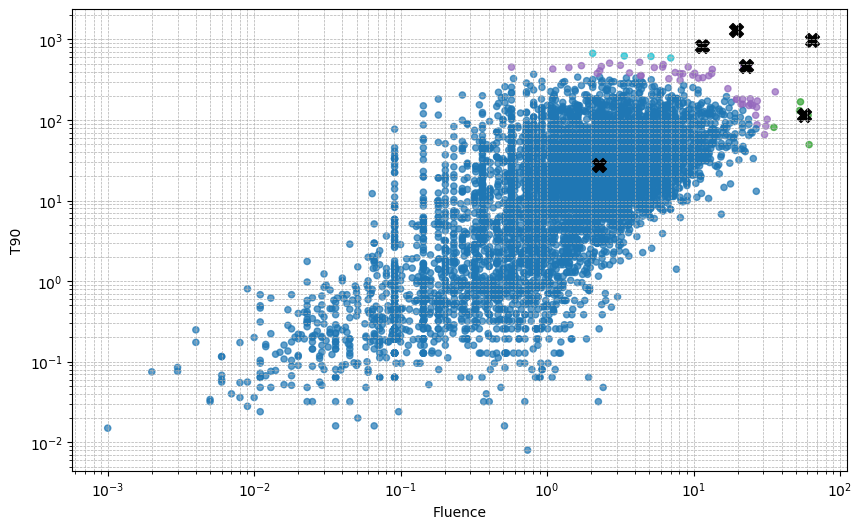

In [44]:
clMS_best = MeanShift(bandwidth=grid_ms.best_params_['bandwidth'])

clMS_best.fit(data_scaled)
labels_MS_best = clMS_best.labels_

plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels_MS_best, cmap='tab10', s=20, alpha=0.7)
plt.scatter(scaler.inverse_transform(clMS_best.cluster_centers_)[:, 0], scaler.inverse_transform(clMS_best.cluster_centers_)[:, 1], c='black', s=100, marker='X', label='Cluster Centers')
plt.xlabel('Fluence')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)